Generating synthetic atomic coordinates for coordination parity...

          RUNNING REFERENCE FRAMEWORK (SciPy)
-> SciPy reference finished.

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy calculation finished.

          PARITY VALIDATION
1. MSE on Coordination Histogram : 0.000000e+00
2. MSE on Avg Neighbor Distance  : 0.000000e+00
3. MSE on Effective Coord Num    : 1.546167e-28

SUCCESS: DimRedPy Coordination descriptors perfectly match rigorous SciPy reference.
Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_descriptors\verify_parity_descriptors_coordination_plot.png


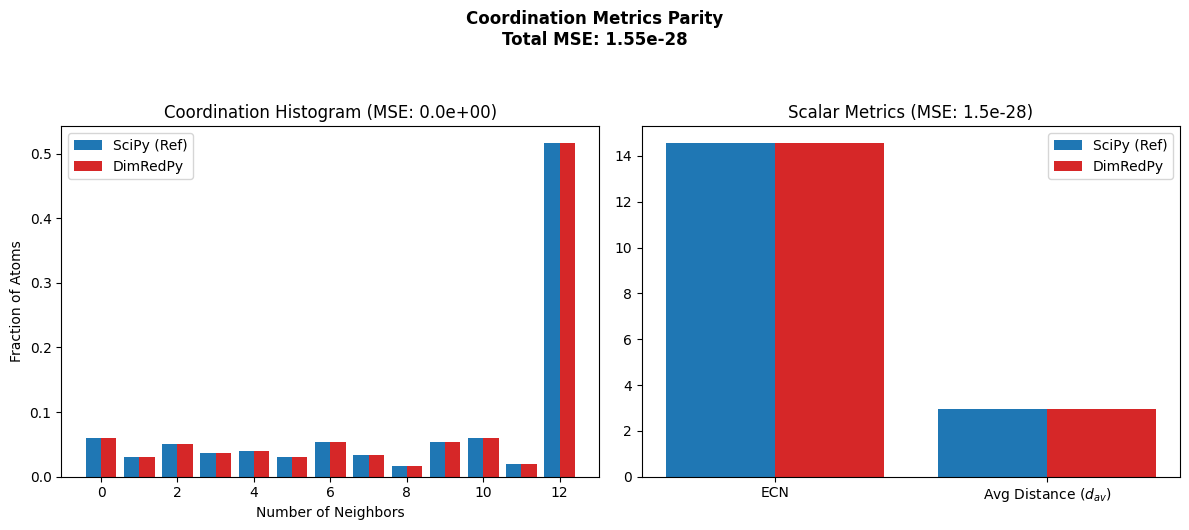

In [1]:
"""
Rigorous Verification of Descriptor Parity: Coordination Metrics
"""

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from dimredpy.shared.descriptors import (
    coordination_histogram,
    effective_coordination_number,
    average_neighbor_distance
)

# ---------------------------------------------------------------------------
# 1. Generate Synthetic Data
# ---------------------------------------------------------------------------
print("Generating synthetic atomic coordinates for coordination parity...")
np.random.seed(42)
N_atoms = 300
positions = np.random.randn(N_atoms, 3) * 5.0

cutoff = 4.0
max_neighbors = 12

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (SciPy cdist explicit iterative calculation)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (SciPy)")
print("=======================================================")

# Compute exact distance matrix
dist_mat = cdist(positions, positions)
np.fill_diagonal(dist_mat, np.inf) # Ignore self

# 1. Reference Coordination Histogram
counts = np.sum(dist_mat < cutoff, axis=1)
counts_clipped = np.clip(counts, 0, max_neighbors)
ref_hist = np.bincount(counts_clipped, minlength=max_neighbors+1) / N_atoms

# 2. Reference Average Neighbor Distance (d_av)
mask = dist_mat < cutoff
pairs = dist_mat[mask]
ref_d_av = np.mean(pairs) if len(pairs) > 0 else 0.0

# 3. Reference Effective Coordination Number (ECN)
# ECN = (1/N) * Sum_i Sum_{j!=i} exp(1 - (d_ij / d_av_i)^6)
ref_ecn_sum = 0.0
for i in range(N_atoms):
    neighbors = dist_mat[i][dist_mat[i] < cutoff]
    if len(neighbors) > 0:
        d_av_i = np.mean(neighbors)
        # Power calculation for all pairs (j!=i)
        power = (dist_mat[i] / d_av_i)**6
        # To match dimredpy implementation, valid pairs (dist < inf)
        # However, dimredpy applies ECN for all j where valid.
        valid = dist_mat[i] < np.inf
        p_clip = np.clip(power[valid], 0, 100)
        ref_ecn_sum += np.sum(np.exp(1.0 - p_clip))

ref_ecn = ref_ecn_sum / N_atoms

print("-> SciPy reference finished.")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

dimredpy_hist = coordination_histogram(positions, cutoff=cutoff, max_neighbors=max_neighbors)
dimredpy_d_av = average_neighbor_distance(positions, cutoff=cutoff)
dimredpy_ecn = effective_coordination_number(positions, cutoff=cutoff)

print("-> DimRedPy calculation finished.")

# ---------------------------------------------------------------------------
# 4. Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

mse_hist = np.mean((ref_hist - dimredpy_hist) ** 2)
mse_d_av = (ref_d_av - dimredpy_d_av) ** 2
mse_ecn = (ref_ecn - dimredpy_ecn) ** 2

print(f"1. MSE on Coordination Histogram : {mse_hist:.6e}")
print(f"2. MSE on Avg Neighbor Distance  : {mse_d_av:.6e}")
print(f"3. MSE on Effective Coord Num    : {mse_ecn:.6e}")

total_mse = mse_hist + mse_d_av + mse_ecn

if total_mse < 1e-10:
    print("\nSUCCESS: DimRedPy Coordination descriptors perfectly match rigorous SciPy reference.")
else:
    print("\nFAILURE: Statistical divergence detected in coordination parity.")

# ---------------------------------------------------------------------------
# 5. Visual Verification
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor='white')
fig.suptitle(f"Coordination Metrics Parity\nTotal MSE: {total_mse:.2e}", fontweight='bold', y=1.05)

# Histogram Plot
x_bins = np.arange(max_neighbors + 1)
axes[0].bar(x_bins - 0.2, ref_hist, width=0.4, label='SciPy (Ref)', color='#1f77b4')
axes[0].bar(x_bins + 0.2, dimredpy_hist, width=0.4, label='DimRedPy', color='#d62728')
axes[0].set_xlabel("Number of Neighbors")
axes[0].set_ylabel("Fraction of Atoms")
axes[0].set_title(f"Coordination Histogram (MSE: {mse_hist:.1e})")
axes[0].legend()

# Scalar values Plot
metrics = ['ECN', 'Avg Distance ($d_{av}$)']
ref_vals = [ref_ecn, ref_d_av]
dimredpy_vals = [dimredpy_ecn, dimredpy_d_av]

x = np.arange(len(metrics))
axes[1].bar(x - 0.2, ref_vals, width=0.4, label='SciPy (Ref)', color='#1f77b4')
axes[1].bar(x + 0.2, dimredpy_vals, width=0.4, label='DimRedPy', color='#d62728')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_title(f"Scalar Metrics (MSE: {mse_ecn+mse_d_av:.1e})")
axes[1].legend()

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_descriptors_coordination_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison plot to {plot_path}")
